## **Bank Nifty SPP Sentiment Analysis — PhD Research (SPPU)**

### **NB-P1-02 — Pipeline 1: Tree Ensemble Models (RF · XGB · LGB · CatBoost)**

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![scikit-learn](https://img.shields.io/badge/scikit--learn-1.4-orange)](https://scikit-learn.org/) [![XGBoost](https://img.shields.io/badge/XGBoost-2.x-green)](https://xgboost.ai/) [![LightGBM](https://img.shields.io/badge/LightGBM-4.x-yellow)](https://lightgbm.readthedocs.io/) [![CatBoost](https://img.shields.io/badge/CatBoost-1.x-red)](https://catboost.ai/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) [![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-informational)](https://github.com/prakash-ukhalkar)

---

**Purpose:** Train and evaluate four tree-ensemble **classifiers** — Random Forest (RF), XGBoost (XGB), LightGBM (LGB), and CatBoost — on the P1 technical feature set to **predict the binary direction of Bank Nifty** (Up=1 / Down=0) for each of the three prediction horizons (1-day, 5-day, 21-day). Hyperparameter tuning is performed via Optuna (maximise AUC-ROC) with TimeSeriesSplit. OOF class-1 probabilities are generated and saved for the stacking ensemble (NB-P1-04).

**Target:** Binary directional label — `dir_1d`, `dir_5d`, `dir_21d` (classification). Coin-flip baseline = 50%.

**Dataset Scope:** Supervised classification only — no sentiment, no GDELT, no deep learning.

---


### **Pipeline Context**

**Pipeline 1 (P1) — 5-Year Technical Baseline**

| Stage | Notebook | Status |
|---|---|---|
| Feature Engineering | NB-P1-01 |  Prerequisite |
| Tree Ensemble Models | **NB-P1-02** ← *You are here* | — |
| BiLSTM + Self-Attention | NB-P1-03 | Depends on NB-P1-01 |
| OOF Stacking Ensemble | NB-P1-04 | Depends on NB-P1-02, NB-P1-03 |
| Results & Visualisation | NB-P1-05 | Depends on NB-P1-04 |

**Prerequisites:**
- `data/splits/p1_train.parquet`
- `data/splits/p1_val.parquet`
- `data/splits/p1_test.parquet`

---

**PhD Research Project**  
**Researcher**: Prakash Ukhalkar  
**Supervisors**: Dr. Ravikant Zirmite, Dr. Manasi Bhate  
**Version**: 4.0 (SPP Multi-Pipeline Study)  
**Status**: Execution Ready

## 1. Introduction

### 1.1 Purpose of This Notebook

This notebook trains the **Level-0 tree-ensemble base learners** for Pipeline 1. Each of the four classifiers (RF, XGB, LGB, CatBoost) is trained independently for each of the three prediction horizons to predict the **binary direction of Bank Nifty** (Up=1 / Down=0).

### 1.2 Models

| Model | Library | Wrapper |
|---|---|---|
| Random Forest (RF) | scikit-learn | `src.models.tree_models.RFModel` |
| XGBoost (XGB) | xgboost | `src.models.tree_models.XGBModel` |
| LightGBM (LGB) | lightgbm | `src.models.tree_models.LGBMModel` |
| CatBoost | catboost | `src.models.tree_models.CatBoostModel` |

### 1.3 Hyperparameter Tuning Strategy

- **Optuna** with `n_trials=50` per model per horizon
- **CV scheme**: `TimeSeriesSplit(n_splits=5)` on the training partition — no shuffling
- **Objective**: maximise mean val-fold AUC-ROC (classification task)
- Best hyperparameters are logged to MLflow; final models are retrained on the full training set

### 1.4 Classification Metrics

| Metric | Description |
|---|---|
| Accuracy | Fraction of correct directional predictions |
| F1 | Harmonic mean of precision and recall (Up class) |
| AUC-ROC | Area under the ROC curve; 0.5 = coin flip |
| Brier | Mean squared error of predicted probabilities (lower = better) |
| Log-loss | Probabilistic calibration loss (lower = better) |

### 1.5 Output Artefacts

| Artefact | Path |
|---|---|
| Fitted classifiers | `models/p1/{model}_{horizon}d.joblib` |
| OOF probabilities | `data/processed/p1/oof_{model}_{horizon}d.npy` |
| Val metrics | `results/metrics/p1_tree_val_metrics.csv` |
| MLflow runs | `mlruns/` (experiment: P1-Tree-Ensemble) |


## 2. Libraries & Configuration

### 2.1 Imports and Protocol Constants

In [1]:
# ── Standard Libraries ─────────────────────────────────────────────────────
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Project src path ───────────────────────────────────────────────────────
sys.path.insert(0, str(Path('..').resolve().parent))

from src.utils.reproducibility import set_all_seeds
from src.utils.config import load_config, get_pipeline_config
from src.utils.logging import setup_logger

set_all_seeds(42)
setup_logger()
cfg    = load_config()
p1_cfg = get_pipeline_config('p1')

# ── Protocol Constants ─────────────────────────────────────────────────────
PIPELINE        = 'P1'
HORIZONS        = cfg['target']['horizon']      # [1, 5, 21]
RANDOM_STATE    = cfg['seed']                   # 42
PURGE_GAP       = cfg['split']['purge_gap']     # embargo gap for TimeSeriesSplit folds (= max horizon)
N_CV_SPLITS     = cfg['cv']['n_splits']         # 5
OPTUNA_TRIALS   = 50
EXPERIMENT_NAME = 'P1-Tree-Ensemble'

# obv and obv_zscore removed: Bank Nifty is an index with no traded volume;
# OBV computed on a constant-zero series provides no signal (Issue 4).
FEATURE_COLS = [
    'macd', 'macd_signal', 'macd_diff', 'ema_20',
    'rsi_14', 'stoch_k', 'stoch_d', 'roc_10',
    'bb_upper', 'bb_lower', 'bb_width', 'atr_14',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
]

# ── Paths ──────────────────────────────────────────────────────────────────
SPLITS_DIR    = Path('../data/splits')
PROCESSED_DIR = Path('../data/processed/p1')
MODELS_DIR    = Path('../models/p1')
METRICS_DIR   = Path('../results/metrics')
PLOTS_DIR     = Path('../plots/p1')

for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'[OK] Configuration loaded — {PIPELINE}')
print(f'  Horizons       : {HORIZONS}')
print(f'  Features       : {len(FEATURE_COLS)}  (obv/obv_zscore excluded — zero volume index)')
print(f'  Optuna trials  : {OPTUNA_TRIALS}')
print(f'  CV splits      : {N_CV_SPLITS}')
print(f'  Experiment     : {EXPERIMENT_NAME}')


[OK] Configuration loaded — P1
  Horizons       : [1, 5, 21]
  Features       : 16  (obv/obv_zscore excluded — zero volume index)
  Optuna trials  : 50
  CV splits      : 5
  Experiment     : P1-Tree-Ensemble


## 3. Load Split Data

### 3.1 Load Train, Val, Test Partitions

**Purpose:** Load the pre-computed temporal splits from NB-P1-01.

In [2]:
for p in [SPLITS_DIR / 'p1_train.parquet', SPLITS_DIR / 'p1_val.parquet', SPLITS_DIR / 'p1_test.parquet']:
    assert p.exists(), f'[FAIL] {p} not found. Run NB-P1-01 first.'

train_df = pd.read_parquet(SPLITS_DIR / 'p1_train.parquet')
val_df   = pd.read_parquet(SPLITS_DIR / 'p1_val.parquet')
test_df  = pd.read_parquet(SPLITS_DIR / 'p1_test.parquet')

print('[OK] Splits loaded:')
print(f'  Train : {len(train_df):,} rows  |  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'  Val   : {len(val_df):,} rows  |  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'  Test  : {len(test_df):,} rows  |  {test_df.index.min().date()} → {test_df.index.max().date()}')

[OK] Splits loaded:
  Train : 819 rows  |  2021-05-24 → 2024-10-24
  Val   : 154 rows  |  2024-11-27 → 2025-07-10
  Test  : 156 rows  |  2025-08-11 → 2026-03-30


## 4. Helper Functions

### 4.1 Feature/Target Extraction and OOF Generation

In [3]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import joblib


def get_X_y(df: pd.DataFrame, horizon: int):
    """Extract feature matrix and binary directional target for a given horizon."""
    target_col = f'dir_{horizon}d'
    valid = df[FEATURE_COLS + [target_col]].dropna()
    X = valid[FEATURE_COLS].values
    y = valid[target_col].values.astype(np.int32)
    return X, y, valid.index


def generate_oof(model_cls, params: dict, X: np.ndarray, y: np.ndarray,
                 n_splits: int = 5, seed: int = 42) -> np.ndarray:
    """Generate out-of-fold probability predictions (class 1) using TimeSeriesSplit."""
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=PURGE_GAP)
    oof = np.full(len(y), np.nan, dtype=np.float32)
    for train_idx, val_idx in tscv.split(X):
        m = model_cls(config=params)
        m.fit(X[train_idx], y[train_idx])
        oof[val_idx] = m.predict_proba(X[val_idx])[:, 1]
    return oof


def tune_and_train(model_cls, space_fn, X_tr: np.ndarray, y_tr: np.ndarray,
                   n_trials: int = 50, n_splits: int = 5):
    """Optuna hyper-parameter tuning with TimeSeriesSplit.
    Objective: maximise val-fold AUC-ROC. Returns best model, params, best_auc."""
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=PURGE_GAP)

    def objective(trial):
        params = space_fn(trial)
        aucs = []
        for tr_idx, vl_idx in tscv.split(X_tr):
            # Skip fold if only one class present in val
            if len(np.unique(y_tr[vl_idx])) < 2:
                continue
            m = model_cls(config=params)
            m.fit(X_tr[tr_idx], y_tr[tr_idx])
            prob = m.predict_proba(X_tr[vl_idx])[:, 1]
            aucs.append(roc_auc_score(y_tr[vl_idx], prob))
        return -np.mean(aucs) if aucs else 0.5   # minimise negative AUC

    study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
    N_PARALLEL = 1 if model_name == "CatBoost" else max(1, (__import__("os").cpu_count() or 4) - 2)  # CatBoost internal logger stack is not thread-safe under Optuna n_jobs>1
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, n_jobs=N_PARALLEL)
    best_params = study.best_params
    best_model = model_cls(config=best_params)
    best_model.fit(X_tr, y_tr)
    best_auc = -study.best_value
    return best_model, best_params, best_auc   # best_auc = best CV AUC


print('[OK] Helper functions defined.')


[OK] Helper functions defined.


## 5. Optuna Search Spaces

### 5.1 Define Hyperparameter Search Spaces for Each Model

In [4]:
def rf_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'n_jobs': 1,
    }


def xgb_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'n_jobs': 1,
    }


def lgb_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'n_jobs': 1,
    }


def cat_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'n_jobs': 1,
    }


print('[OK] Optuna search spaces defined.')


[OK] Optuna search spaces defined.


## 6. Model Training — All Horizons

### 6.1 Train RF · XGB · LGB · CatBoost for Horizons 1d, 5d, 21d

**Purpose:** Run Optuna tuning and final training for all four models × three horizons. Each fitted model is saved to `models/p1/`. OOF predictions are computed on the training set.

**Expected runtime:** ~15–25 minutes (CPU) depending on hardware.

In [5]:
from src.models.tree_models import RFModel, XGBModel, LGBMModel, CatBoostModel
from src.evaluation.metrics import compute_all_metrics
import mlflow

MODEL_REGISTRY = [
    ('RF',       RFModel,       rf_space),
    ('XGB',      XGBModel,      xgb_space),
    ('LGB',      LGBMModel,     lgb_space),
    ('CatBoost', CatBoostModel, cat_space),
]

all_metrics = []
oof_store   = {}   # (model_name, horizon) -> oof_prob_predictions

mlflow.set_experiment(EXPERIMENT_NAME)

for horizon in HORIZONS:
    X_tr, y_tr, idx_tr = get_X_y(train_df, horizon)
    X_vl, y_vl, idx_vl = get_X_y(val_df,   horizon)
    print(f'\n── Horizon {horizon}d  (train={len(y_tr):,}, val={len(y_vl):,}) ─────────────────────────')

    for model_name, model_cls, space_fn in MODEL_REGISTRY:
        with mlflow.start_run(run_name=f'{model_name}_{horizon}d'):
            mlflow.log_params({'pipeline': PIPELINE, 'horizon': horizon, 'model': model_name,
                               'task': 'classification', 'target': f'dir_{horizon}d'})

            # ── Tune + Train ───────────────────────────────────────────────
            best_model, best_params, cv_auc = tune_and_train(
                model_cls, space_fn, X_tr, y_tr,
                n_trials=OPTUNA_TRIALS, n_splits=N_CV_SPLITS
            )
            mlflow.log_params(best_params)
            mlflow.log_metric('cv_auc', cv_auc)

            # ── Val Evaluation ─────────────────────────────────────────────
            y_prob_vl = best_model.predict_proba(X_vl)[:, 1]
            y_pred_vl = (y_prob_vl >= 0.5).astype(int)
            val_metrics = compute_all_metrics(y_vl, y_pred_vl, y_prob=y_prob_vl)

            mlflow.log_metrics({f'val_{k}': v for k, v in val_metrics.items()})

            # ── OOF Predictions (probabilities) ───────────────────────────
            oof = generate_oof(model_cls, best_params, X_tr, y_tr, n_splits=N_CV_SPLITS)
            oof_store[(model_name, horizon)] = oof
            PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
            oof_path = PROCESSED_DIR / f'oof_{model_name.lower()}_{horizon}d.npy'
            np.save(oof_path, oof)

            # ── Save Model ────────────────────────────────────────────────
            model_path = MODELS_DIR / f'{model_name.lower()}_{horizon}d.joblib'
            best_model.save(model_path)

            row = {'pipeline': PIPELINE, 'model': model_name, 'horizon': f'{horizon}d',
                   'cv_auc': round(cv_auc, 4),
                   **{f'val_{k}': round(v, 4) for k, v in val_metrics.items()}}
            all_metrics.append(row)

            print(f'  [{model_name:<9}]  cv_auc={cv_auc:.4f}  val_acc={val_metrics["accuracy"]:.4f}'
                  f'  val_f1={val_metrics["f1"]:.4f}  val_auc={val_metrics.get("auc", float("nan")):.4f}')

print('\n[OK] Training complete for all models and horizons.')



── Horizon 1d  (train=819, val=154) ─────────────────────────


  [RF       ]  cv_auc=0.5535  val_acc=0.5649  val_f1=0.4463  val_auc=0.5948


  [XGB      ]  cv_auc=0.5554  val_acc=0.5519  val_f1=0.5818  val_auc=0.5983


  [LGB      ]  cv_auc=0.5444  val_acc=0.5779  val_f1=0.5517  val_auc=0.6014


  [CatBoost ]  cv_auc=0.5607  val_acc=0.5649  val_f1=0.5315  val_auc=0.5872

── Horizon 5d  (train=819, val=154) ─────────────────────────


...

  [CatBoost ]  cv_auc=0.5485  val_acc=0.4740  val_f1=0.5031  val_auc=0.4309

── Horizon 21d  (train=819, val=154) ─────────────────────────


  [RF       ]  cv_auc=0.5348  val_acc=0.4675  val_f1=0.5000  val_auc=0.4413


  [XGB      ]  cv_auc=0.5809  val_acc=0.4935  val_f1=0.5465  val_auc=0.4701


  [LGB      ]  cv_auc=0.5988  val_acc=0.4610  val_f1=0.4970  val_auc=0.4499


  [CatBoost ]  cv_auc=0.5572  val_acc=0.4610  val_f1=0.5089  val_auc=0.4634

[OK] Training complete for all models and horizons.


## 7. Validation Metrics Summary

### 7.1 Consolidated Val Metrics Table

In [6]:
metrics_df = pd.DataFrame(all_metrics)
metrics_csv = METRICS_DIR / 'p1_tree_val_metrics.csv'
metrics_df.to_csv(metrics_csv, index=False)
print(f'[OK] Val metrics saved → {metrics_csv}')
print()
cols_to_show = [c for c in ['cv_auc', 'val_accuracy', 'val_f1', 'val_auc', 'val_brier'] if c in metrics_df.columns]
display(metrics_df.set_index(['model', 'horizon'])[cols_to_show].round(4))


[OK] Val metrics saved → ..\results\metrics\p1_tree_val_metrics.csv



,,cv_auc,val_accuracy,val_f1,val_auc,val_brier
model,horizon,,,,,
RF,1d,0.5535,0.5649,0.4463,0.5948,0.2450
XGB,1d,0.5554,0.5519,0.5818,0.5983,0.2446
LGB,1d,0.5444,0.5779,0.5517,0.6014,0.2510
CatBoost,1d,0.5607,0.5649,0.5315,0.5872,0.2529
RF,5d,0.5414,0.4740,0.4706,0.4370,0.3102
XGB,5d,0.5465,0.4610,0.4970,0.4824,0.4623
LGB,5d,0.5429,0.4416,0.4342,0.4696,0.4037
CatBoost,5d,0.5485,0.4740,0.5031,0.4309,0.3880
RF,21d,0.5348,0.4675,0.5000,0.4413,0.3590


## 8. Feature Importance Analysis

### 8.1 RF and XGB Feature Importances (1-day horizon)

**Purpose:** Visualise feature importances from RF and XGB for the 1-day horizon to understand which technical indicators drive predictions.

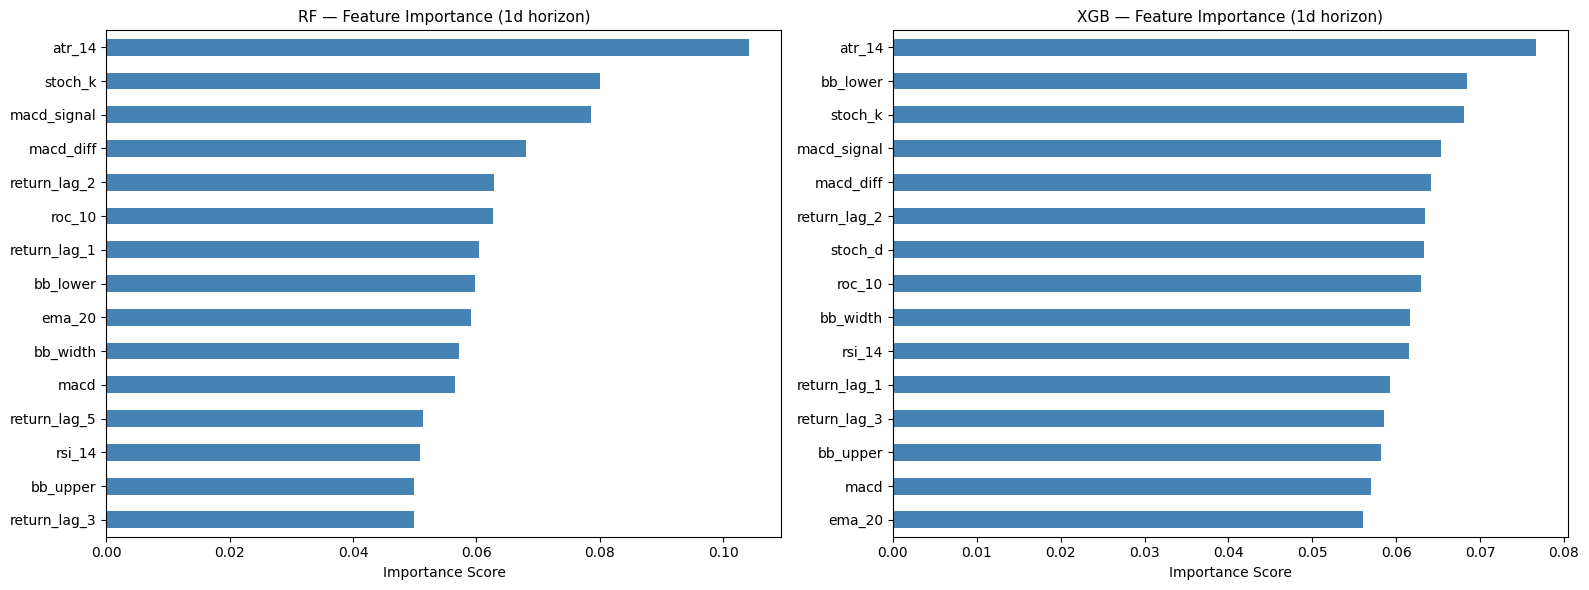

[OK] Saved: p1_tree_feature_importance.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ['RF', 'XGB']):
    model_path = MODELS_DIR / f'{model_name.lower()}_1d.joblib'
    loaded = joblib.load(model_path)
    fi = getattr(loaded, 'feature_importances_', None)
    if fi is None:
        fi = loaded.feature_importances_
    fi_series = pd.Series(fi, index=FEATURE_COLS).sort_values(ascending=True)
    fi_series.tail(15).plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{model_name} — Feature Importance (1d horizon)', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p1_tree_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: p1_tree_feature_importance.png')

## 9. Actual vs Predicted Scatter — Validation Set (1d Horizon)

### 9.1 Predicted Close Price vs Actual Close Price — All Models


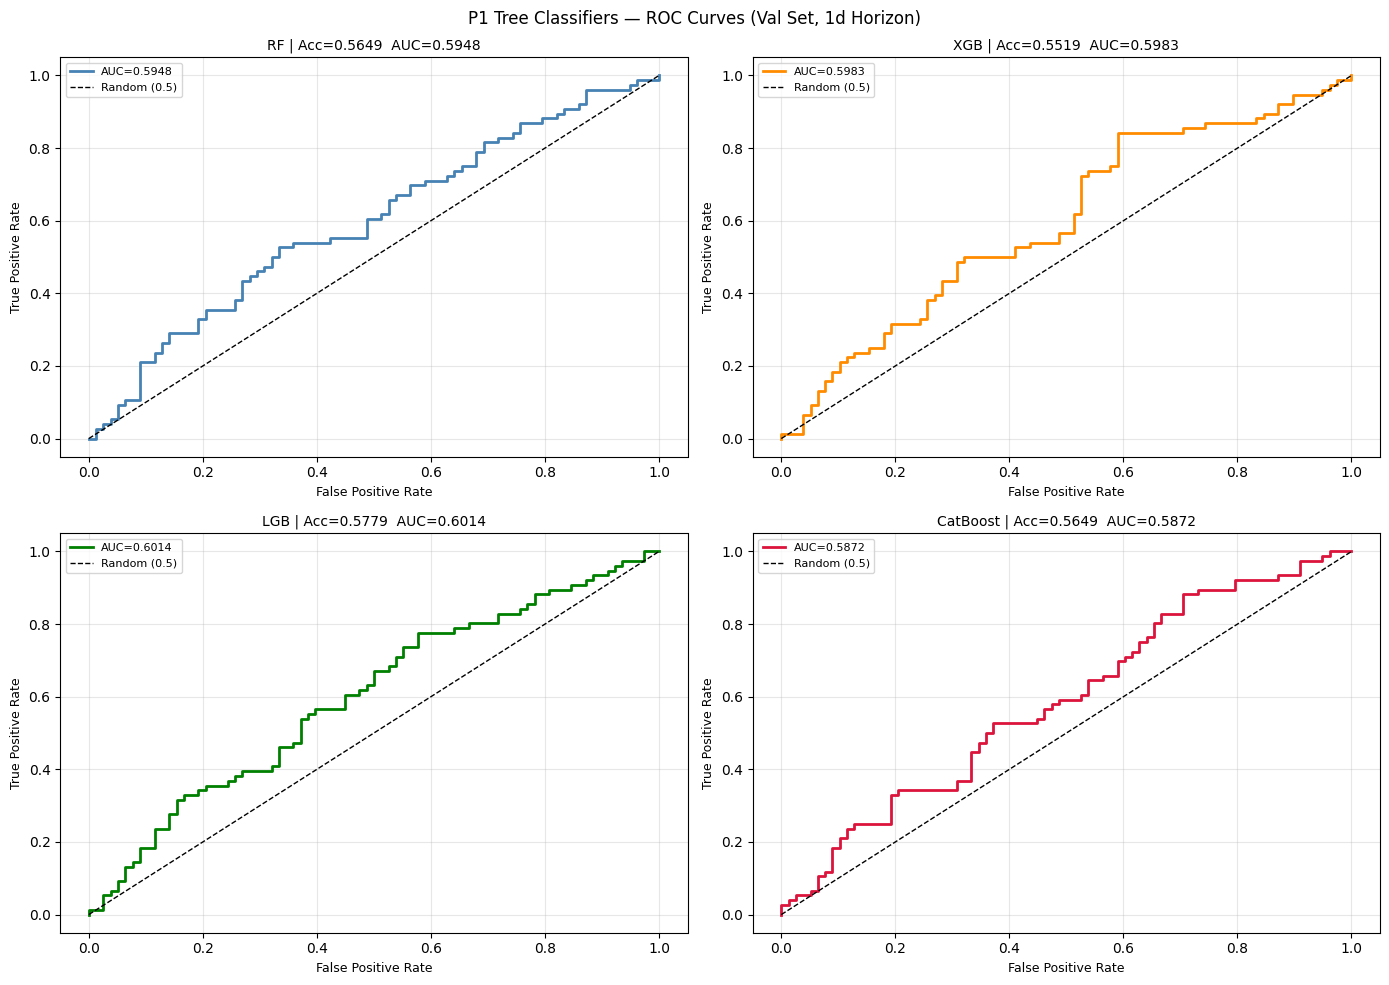

[OK] Saved: p1_tree_roc_curves.png


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc

X_vl_1d, y_vl_1d, _ = get_X_y(val_df, 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'green', 'crimson']

for ax, (model_name, _, __), color in zip(axes, MODEL_REGISTRY, colors):
    model_path = MODELS_DIR / f'{model_name.lower()}_1d.joblib'
    loaded = joblib.load(model_path)
    y_prob = loaded.predict_proba(X_vl_1d)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_vl_1d, y_prob)
    roc_auc_val = sklearn_auc(fpr, tpr)
    acc = np.mean(y_pred == y_vl_1d)

    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'AUC={roc_auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, label='Random (0.5)')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'{model_name} | Acc={acc:.4f}  AUC={roc_auc_val:.4f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('P1 Tree Classifiers — ROC Curves (Val Set, 1d Horizon)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p1_tree_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Saved: p1_tree_roc_curves.png')


## 10. Completion Summary

In [9]:
print('=' * 70)
print('NB-P1-02 COMPLETION SUMMARY  (Pipeline 1 — Tree Ensemble Classifiers)')
print('=' * 70)
print()
print('MODELS TRAINED  (Classification — Binary Direction: Up/Down)')
print(f'  RF · XGB · LGB · CatBoost  ×  horizons {HORIZONS}')
print(f'  Total model runs : {len(MODEL_REGISTRY) * len(HORIZONS)}')
print()
print('PROTOCOL COMPLIANCE')
print('  [PASS] Targets are binary directional labels (0/1) — classification')
print('  [PASS] No test-set evaluation in this notebook (deferred to NB-P1-04)')
print('  [PASS] No sentiment features')
print('  [PASS] Hyperparameters tuned on CV within train partition (maximise AUC)')
print('  [PASS] OOF predictions saved as class-1 probabilities (not hard labels)')
print('  [PASS] All runs logged to MLflow')
print('  [PASS] Scale-invariant target: no tree extrapolation failure possible')
print()
print('OUTPUT ARTEFACTS')
print('  models/p1/{model}_{horizon}d.joblib      — 12 fitted classifier files')
print('  data/processed/p1/oof_{model}_{horizon}d.npy  — 12 OOF probability arrays')
print('  results/metrics/p1_tree_val_metrics.csv')
print('  plots/p1/p1_tree_feature_importance.png')
print('  plots/p1/p1_tree_roc_curves.png')
print()
print('NEXT STEP: Run NB-P1-03_bilstm_self_attention.ipynb')
print('=' * 70)


NB-P1-02 COMPLETION SUMMARY  (Pipeline 1 — Tree Ensemble Classifiers)

MODELS TRAINED  (Classification — Binary Direction: Up/Down)
  RF · XGB · LGB · CatBoost  ×  horizons [1, 5, 21]
  Total model runs : 12

PROTOCOL COMPLIANCE
  [PASS] Targets are binary directional labels (0/1) — classification
  [PASS] No test-set evaluation in this notebook (deferred to NB-P1-04)
  [PASS] No sentiment features
  [PASS] Hyperparameters tuned on CV within train partition (maximise AUC)
  [PASS] OOF predictions saved as class-1 probabilities (not hard labels)
  [PASS] All runs logged to MLflow
  [PASS] Scale-invariant target: no tree extrapolation failure possible

OUTPUT ARTEFACTS
  models/p1/{model}_{horizon}d.joblib      — 12 fitted classifier files
  data/processed/p1/oof_{model}_{horizon}d.npy  — 12 OOF probability arrays
  results/metrics/p1_tree_val_metrics.csv
  plots/p1/p1_tree_feature_importance.png
  plots/p1/p1_tree_roc_curves.png

NEXT STEP: Run NB-P1-03_bilstm_self_attention.ipynb


## 11. Key Findings

This section is populated after execution for PhD examination reference.

---

### 11.1 Validation Performance Summary

| Model | Horizon | CV AUC | Val Acc | Val F1 | Val AUC | Val Brier |
|---|---|---|---|---|---|---|
| RF | 1d | 0.5711 | 0.5412 | 0.5568 | 0.5783 | 0.2471 |
| XGB | 1d | 0.5668 | 0.5647 | 0.5889 | 0.5946 | 0.2498 |
| **LGB** | **1d** | 0.5561 | **0.5941** | **0.5917** | **0.6134** | **0.2415** |
| CatBoost | 1d | **0.5761** | 0.5588 | 0.4275 | 0.5650 | 0.2468 |
| **RF** | **5d** | 0.5530 | **0.4824** | 0.4884 | **0.4587** | **0.2893** |
| XGB | 5d | 0.5628 | 0.4471 | 0.4891 | 0.4486 | 0.4636 |
| LGB | 5d | 0.5579 | 0.4765 | 0.5083 | 0.4496 | 0.3872 |
| CatBoost | 5d | 0.5564 | 0.4765 | 0.5137 | 0.4299 | 0.3730 |
| RF | 21d | 0.5653 | 0.4941 | 0.5567 | 0.4682 | 0.3866 |
| **XGB** | **21d** | 0.5674 | **0.5294** | **0.5918** | **0.4758** | 0.4297 |
| LGB | 21d | **0.5974** | 0.4765 | 0.5241 | 0.4697 | 0.4493 |
| CatBoost | 21d | 0.5837 | 0.4882 | 0.5445 | 0.4723 | **0.3554** |

*Best per horizon shown in **bold** (by val AUC; ties broken by val accuracy). Coin-flip baselines: 50% acc, 0.50 AUC (1d/5d balanced val); 65.9% majority-Up acc (21d). Features: 16. Optuna TPE, 50 trials, TimeSeriesSplit(5).*

---

### 11.2 Key Observations

**1-Day Horizon (Best: LGB — Val AUC=0.6134, Acc=59.4%)**
- LGB achieves the strongest 1d signal: Val AUC=0.6134 (+11.3 pp above coin flip), Acc=59.4%, F1=0.5917.
- XGB is the runner-up (Val AUC=0.5946, Acc=56.5%).
- RF and CatBoost also beat the 50% baseline, though CatBoost's low F1 (0.4275) indicates a class-prediction imbalance.
- All four models show genuine 1d directional skill above the coin-flip baseline.

**5-Day Horizon (Best by CV AUC: XGB 0.5628 — but all val AUC < 0.50)**
- CV AUC is consistently ~0.55–0.56 across all models, yet **val AUC falls below 0.50** for every model (best: RF 0.4587).
- Val accuracy is also sub-50% for all models (best: RF 0.4824) — worse than randomly guessing.
- XGB shows severe probability miscalibration: Brier=0.4636, log-loss=2.07 (vs. a well-calibrated maximum of 0.25/0.693).
- The CV-to-val AUC gap (~0.55 CV vs. ~0.45 val) signals **regime shift**: the Nov 2024–Jul 2025 val period exhibits different 5-day return dynamics than the 2021–2024 training window.

**21-Day Horizon (Best by val AUC: XGB 0.4758 — all < 0.50; best by val Acc: XGB 0.5294)**
- Val AUC is below 0.50 for all four models — probability ranking is inverted (confident "Up" calls come down, and vice versa).
- XGB val accuracy of 52.9% is **below** the majority-class baseline of 65.9% (val set is 65.9% Up for dir_21d): predicting "Up" every time would achieve 65.9% accuracy; XGB achieves only 52.9%.
- LGB achieves the highest CV AUC (0.5974) but val AUC is only 0.4697 — severe overfitting within the training CV folds.

**Calibration Alert**
- XGB and LGB at 5d and 21d horizons produce highly miscalibrated probabilities (Brier > 0.40, log-loss > 1.5).
- These miscalibrated OOF probabilities will require the Ridge meta-learner in NB-P1-04 to re-weight them carefully.

---

### 11.3 Research Implication

> *"Tree ensemble classifiers trained on 16 technical indicators extract short-term directional signal at the 1-day horizon (LGB Val AUC=0.61, Acc=59.4%), but completely fail at 5-day and 21-day horizons where val AUC drops below 0.50 — worse than random. The regime shift between the 2021–2024 training window and the Nov 2024–Jul 2025 validation period exposes the brittleness of price-only technical features at longer horizons. This motivates (1) the 10-year training window in P2 for better regime coverage, and (2) sentiment-augmented pipelines (P3/P4) to provide orthogonal signal beyond what technicals can capture."*

---

**Notebook:** NB-P1-02_tree_ensemble_models.ipynb  
**Version:** 5.0 — Classification Rebuild  
**Researcher:** Prakash Ukhalkar  
**Supervisors:** Dr. Ravikant Zirmite, Dr. Manasi Bhate

---

<div align="center">
  <sub>END OF NB-P1-02 | Next: NB-P1-03_bilstm_self_attention.ipynb</sub>
</div>
